#Project Name: Glassdoor Jobs Salary Prediction
### Project Type: Data Science + EDA + Machine Learning Regression + Web Deployment
###Contribution: Individual

##Project Summary:
###This project analyzes job posting from Glassdoor to understand salary trends in the data science and technology job market. The dataset contains information such as job title, salary estimate, company name, location, company size, industry, sector, revenue, and job predictions. The main objective of this project is to explore the factors that influence salaries and build a machine learning model capable of predicting the estimated salary of a job based on its attributes.

##Problem Statement:
###Salary information is an important factor for job seeker, employers, and researchers. However, salaries can vary significantl depending on factors such as job title, location, industry, company size, company rating, and required skills. The objective of this project is to analyze Glassdoor job posting data, identify important features affecting salary, and deploy a machine learning model that can predict the estimated salary for a job based on its available attributes.

##Business Context:
### Salary is an important factor for job seekers when evaluating career opportunities. However, salaries for similar jobs can vary depending on job title, location, industry, company size, company rating, and othr company-related factors.
###For employers, understanding salary patterns can help them offer cmpetitive compensation and attract suitable candidates.
###This project analyzes Glassdoor job posting data to undestand salary trends and identity factors associated with salary differences. A machine learning regression model is developed to predict the estimated average salary of a job  based on its available attributes.
##Business Objectives:
###1. Analyze salary trends in Glassdoor job postings.
###2. Identify factors associated with salary differences.
###3. Compare salaries across job titles and location.
###4. Analyze salary differences across industries and company characteristics.
###5. Build a machine learning model to predict estimated average salary.


##Import Libraries:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


##Load dataset:

In [ ]:
df = pd.read_csv('/content/glassdoor_jobs.csv')

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (956, 15)


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


##Data Understanding:


In [ ]:
#1.data understanding
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 956
Number of Columns: 15


In [ ]:
#Columns Name
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')

In [ ]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112.2+ KB


In [ ]:
#statistical summary
df.describe()

,Unnamed: 0,Rating,Founded
count,956.000000,956.000000,956.000000
mean,477.500000,3.601255,1774.605649
std,276.117729,1.067619,598.942517
min,0.000000,-1.000000,-1.000000
25%,238.750000,3.300000,1937.000000
50%,477.500000,3.800000,1992.000000
75%,716.250000,4.200000,2008.000000
max,955.000000,5.000000,2019.000000


In [ ]:
# CHECK MISSING VALUES
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)#checking missing value


Missing values in each column:
Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: int64


In [ ]:
#CHECK DUPLICATE ROWS
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


##Initial Observation:
###1. The dataset contains information about Glassdoor job postings.
###2. The dataset include job titles, salary estimates, company information, location,industry, sector, revenue, and job descriptions.
###3. The target variable for this project will be created from the **Salary Estimate** column.
###4. further data cleaning and Preprocessing are required before building a machine learning model.

##Data Cleaning:

In [ ]:
#CREATE CLEANING COPY
df_clean = df.copy()

print("Copy created successfully.")
df_clean.head()

Copy created successfully.


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [ ]:
#REMOVE UNNECESSARY INDEX COLUMN
if 'Unnamed: 0' in df_clean.columns:
    df_clean.drop(columns=['Unnamed: 0'], inplace=True)

print("Shape after removing unnecessary column:", df_clean.shape)

Shape after removing unnecessary column: (956, 14)


In [ ]:
# CHECK SALARY ESTIMATE
print("First 20 Salary Estimate values:")
print(df_clean['Salary Estimate'].head(20))

print("\nUnique salary formats:")
print(df_clean['Salary Estimate'].unique()[:20])

First 20 Salary Estimate values:
0       $53K-$91K (Glassdoor est.)
1      $63K-$112K (Glassdoor est.)
2       $80K-$90K (Glassdoor est.)
3       $56K-$97K (Glassdoor est.)
4      $86K-$143K (Glassdoor est.)
5      $71K-$119K (Glassdoor est.)
6       $54K-$93K (Glassdoor est.)
7      $86K-$142K (Glassdoor est.)
8       $38K-$84K (Glassdoor est.)
9     $120K-$160K (Glassdoor est.)
10    $126K-$201K (Glassdoor est.)
11     $64K-$106K (Glassdoor est.)
12    $106K-$172K (Glassdoor est.)
13      $46K-$85K (Glassdoor est.)
14     $83K-$144K (Glassdoor est.)
15    $102K-$190K (Glassdoor est.)
16     $67K-$137K (Glassdoor est.)
17    $118K-$189K (Glassdoor est.)
18    $110K-$175K (Glassdoor est.)
19     $64K-$111K (Glassdoor est.)
Name: Salary Estimate, dtype: object

Unique salary formats:
['$53K-$91K (Glassdoor est.)' '$63K-$112K (Glassdoor est.)'
 '$80K-$90K (Glassdoor est.)' '$56K-$97K (Glassdoor est.)'
 '$86K-$143K (Glassdoor est.)' '$71K-$119K (Glassdoor est.)'
 '$54K-$93K (Glassdoor est

In [ ]:
# CLEAN SALARY TEXT
df_clean['Salary Estimate'] = (
    df_clean['Salary Estimate']
    .astype(str)
    .str.replace('(Glassdoor est.)', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace('K', '', regex=False)
    .str.strip()
)

print("Salary column after text cleaning:")
print(df_clean['Salary Estimate'].head(20))

Salary column after text cleaning:
0       53-91
1      63-112
2       80-90
3       56-97
4      86-143
5      71-119
6       54-93
7      86-142
8       38-84
9     120-160
10    126-201
11     64-106
12    106-172
13      46-85
14     83-144
15    102-190
16     67-137
17    118-189
18    110-175
19     64-111
Name: Salary Estimate, dtype: object


In [ ]:
# EXTRACT MINIMUM AND MAXIMUM SALARY
# Extract only salary ranges such as:
# 53-91
# 63-112
# 80-90

salary_extracted = df_clean['Salary Estimate'].str.extract(
    r'^(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)$'
)

df_clean['Min Salary'] = pd.to_numeric(
    salary_extracted[0],
    errors='coerce'
)

df_clean['Max Salary'] = pd.to_numeric(
    salary_extracted[1],
    errors='coerce'
)

# Calculate average salary
df_clean['Average Salary'] = (
    df_clean['Min Salary'] +
    df_clean['Max Salary']
) / 2

print("Salary extraction completed.")

df_clean[
    ['Salary Estimate', 'Min Salary', 'Max Salary', 'Average Salary']
].head(10)

Salary extraction completed.


,Salary Estimate,Min Salary,Max Salary,Average Salary
0,53-91,53.0,91.0,72.0
1,63-112,63.0,112.0,87.5
2,80-90,80.0,90.0,85.0
3,56-97,56.0,97.0,76.5
4,86-143,86.0,143.0,114.5
5,71-119,71.0,119.0,95.0
6,54-93,54.0,93.0,73.5
7,86-142,86.0,142.0,114.0
8,38-84,38.0,84.0,61.0
9,120-160,120.0,160.0,140.0


In [ ]:
# CHECK INVALID SALARY VALUES
invalid_salary_count = df_clean[
    df_clean['Average Salary'].isnull()
].shape[0]

print("Number of rows with invalid/non-standard salary:", invalid_salary_count)

print("\nInvalid salary examples:")
print(
    df_clean.loc[
        df_clean['Average Salary'].isnull(),
        'Salary Estimate'
    ].value_counts().head(20)
)

Number of rows with invalid/non-standard salary: 264

Invalid salary examples:
Salary Estimate
-1                                         214
21-34 Per Hour                               6
18-25 Per Hour                               4
190-220(Employer est.)                       3
Employer Provided Salary:25-28 Per Hour      3
24-39 Per Hour                               3
Employer Provided Salary:100-140             3
Employer Provided Salary:120-145             2
110-150(Employer est.)                       2
82-129(Employer est.)                        2
10-17 Per Hour                               2
Employer Provided Salary:200-250             2
17-24 Per Hour                               2
Employer Provided Salary:150-160             2
21-29 Per Hour                               2
Employer Provided Salary:110-130             2
90-110(Employer est.)                        2
200-275(Employer est.)                       1
80-105(Employer est.)                        1
15-25 Per Ho

In [ ]:
# REMOVE INVALID SALARY ROWS
df_clean = df_clean.dropna(
    subset=[
        'Min Salary',
        'Max Salary',
        'Average Salary'
    ]
).copy()

print("Shape after removing invalid salary rows:")
print(df_clean.shape)

Shape after removing invalid salary rows:
(692, 17)


In [ ]:
# VERIFY SALARY VALUES
print(
    df_clean[
        ['Min Salary', 'Max Salary', 'Average Salary']
    ].isnull().sum()
)

print("\nFinal dataset shape after salary cleaning:")
print(df_clean.shape)

Min Salary        0
Max Salary        0
Average Salary    0
dtype: int64

Final dataset shape after salary cleaning:
(692, 17)


In [ ]:
# DATA INFORMATION AFTER CLEANING
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 692 entries, 0 to 955
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          692 non-null    object 
 1   Salary Estimate    692 non-null    object 
 2   Job Description    692 non-null    object 
 3   Rating             692 non-null    float64
 4   Company Name       692 non-null    object 
 5   Location           692 non-null    object 
 6   Headquarters       692 non-null    object 
 7   Size               692 non-null    object 
 8   Founded            692 non-null    int64  
 9   Type of ownership  692 non-null    object 
 10  Industry           692 non-null    object 
 11  Sector             692 non-null    object 
 12  Revenue            692 non-null    object 
 13  Competitors        692 non-null    object 
 14  Min Salary         692 non-null    float64
 15  Max Salary         692 non-null    float64
 16  Average Salary     692 non-null

##Hypothesis and Assumptions
###Hypothesis 1:
Job title is associated with salary differences.
###Hypothesis 2:
Location is associated with salary differences.
###Hypothesis 3:
Industry and sector may influence salary levels.
###Hypothesis 4:
Compan rating may have an association with salary.

###Assumptions:
1. The salary estimated represents the annual salary range provided by Glassdoor.
2. Average Salary is calculated as the midpoint of the minimum and maximum salary.
3. Invalid or unavilable salary estimaes are excluded from the analysis.
4. The availabe job attributes are assumed to contain useful information for salary prediction.


In [ ]:
# UNIQUE VALUES
categorical_summary = (
    df_clean
    .select_dtypes(include='object')
    .nunique()
    .sort_values(ascending=False)
)

print("Number of unique values in categorical columns:")
print(categorical_summary)

Number of unique values in categorical columns:
Job Description      437
Salary Estimate      392
Company Name         321
Job Title            245
Location             191
Headquarters         185
Competitors          124
Industry              59
Sector                24
Revenue               13
Type of ownership     10
Size                   8
dtype: int64


In [ ]:
# REMOVE UNNECESSARY COLUMNS
columns_to_remove = [
    'Salary Estimate',
    'Job Description',
    'Company Name'
]

df_clean = df_clean.drop(
    columns=columns_to_remove,
    errors='ignore'
)

print("Remaining columns:")
print(df_clean.columns.tolist())

print("\nShape:", df_clean.shape)

Remaining columns:
['Job Title', 'Rating', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Min Salary', 'Max Salary', 'Average Salary']

Shape: (692, 14)


##Separate Features(x) and traget(y):

In [ ]:
# FEATURES AND TARGET
X = df_clean.drop(
    columns=[
        'Average Salary',
        'Min Salary',
        'Max Salary'
    ]
)

Y = df_clean['Average Salary']

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget:")
print("Average Salary")

X shape: (692, 11)
Y shape: (692,)

Feature columns:
['Job Title', 'Rating', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors']

Target:
Average Salary


In [ ]:
# IDENTIFY COLUMN TYPES
categorical_cols = X.select_dtypes(
    include='object'
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude='object'
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Job Title', 'Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors']

Numerical columns:
['Rating', 'Founded']


In [ ]:
# TRAIN-TEST SPLIT
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (553, 11)
Testing data: (139, 11)


##Create the preprocessing pipeline:

In [ ]:
# PREPROCESSING PIPELINE
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            'numerical',
            'passthrough',
            numerical_cols
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [ ]:
#LINEAR REGRESSION
lr_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Train model
lr_model.fit(X_train, Y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# LINEAR REGRESSION EVALUATION
mae_lr = mean_absolute_error(
    Y_test,
    y_pred_lr
)

mse_lr = mean_squared_error(
    Y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(
    Y_test,
    y_pred_lr
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 260.74468541089965
MSE : 471987.48005706817
RMSE: 687.0134496915385
R2  : -364.9283085127922


In [ ]:
# RANDOM FOREST
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2
            )
        )
    ]
)

rf_model.fit(X_train, Y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# RANDOM FOREST EVALUATION
mae_rf = mean_absolute_error(
    Y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    Y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    Y_test,
    y_pred_rf
)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest Results
---------------------
MAE : 22.360933108792203
MSE : 810.764761910712
RMSE: 28.473931268982017
R2  : 0.3714202379014553


In [ ]:
# MODEL COMPARISON
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_rf
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf
    ],
    'R2': [
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,260.744685,687.013450,-364.928309
1,Random Forest,22.360933,28.473931,0.371420


In [ ]:
# SELECT BEST MODEL
best_model_name = results.loc[
    results['R2'].idxmax(),
    'Model'
]

print("Best model based on R2:", best_model_name)

if best_model_name == 'Linear Regression':
    final_model = lr_model
else:
    final_model = rf_model

Best model based on R2: Random Forest


In [ ]:
# CROSS-VALIDATION FOR BOTH MODELS

lr_cv_scores = cross_val_score(
    lr_model,
    X,
    Y,
    cv=5,
    scoring='r2'
)

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    Y,
    cv=5,
    scoring='r2'
)

print("Linear Regression - 5 Fold CV")
print("Scores:", lr_cv_scores)
print("Mean R2:", lr_cv_scores.mean())
print("Std:", lr_cv_scores.std())

print("\nRandom Forest - 5 Fold CV")
print("Scores:", rf_cv_scores)
print("Mean R2:", rf_cv_scores.mean())
print("Std:", rf_cv_scores.std())

Linear Regression - 5 Fold CV
Scores: [-4.57847196e-01 -6.06489584e+02 -4.91116921e+02 -1.47963255e+03
 -6.66239266e+03]
Mean R2: -1848.0179131377033
Std: 2453.9748602065138

Random Forest - 5 Fold CV
Scores: [0.24972465 0.29862131 0.47840728 0.53624321 0.40349858]
Mean R2: 0.3932990039708703
Std: 0.10710551433317915


In [ ]:
# MACHINE LEARNING INSIGHT
if r2_lr > r2_rf:
    print("""
Linear Regression performs better than Random Forest
on the test dataset based on MAE, RMSE, and R2.

Therefore, Linear Regression is selected as the final model.
""")
else:
    print("""
Random Forest performs better than Linear Regression
on the test dataset based on R2.

Therefore, Random Forest is selected as the final model.
""")



Random Forest performs better than Linear Regression
on the test dataset based on R2.

Therefore, Random Forest is selected as the final model.



##Data Visualization and Exploratory Analysis:


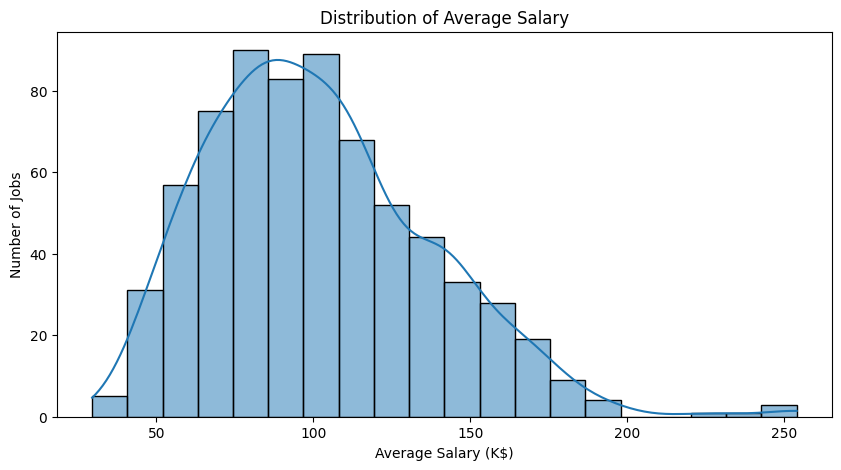

In [ ]:
# SALARY DISTRIBUTION

plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean['Average Salary'],
    bins=20,
    kde=True
)

plt.title('Distribution of Average Salary')
plt.xlabel('Average Salary (K$)')
plt.ylabel('Number of Jobs')
plt.show()

###Insights:
The distribution of average salary is right-skewed. Most job postings have average salaries concentrated between approximately 50k and 120k, with the highest concentration around 70k-110k. Fewer jobs offer higher salaries, particularly above 150k, and only a small number of job posting have salaries above 200k.


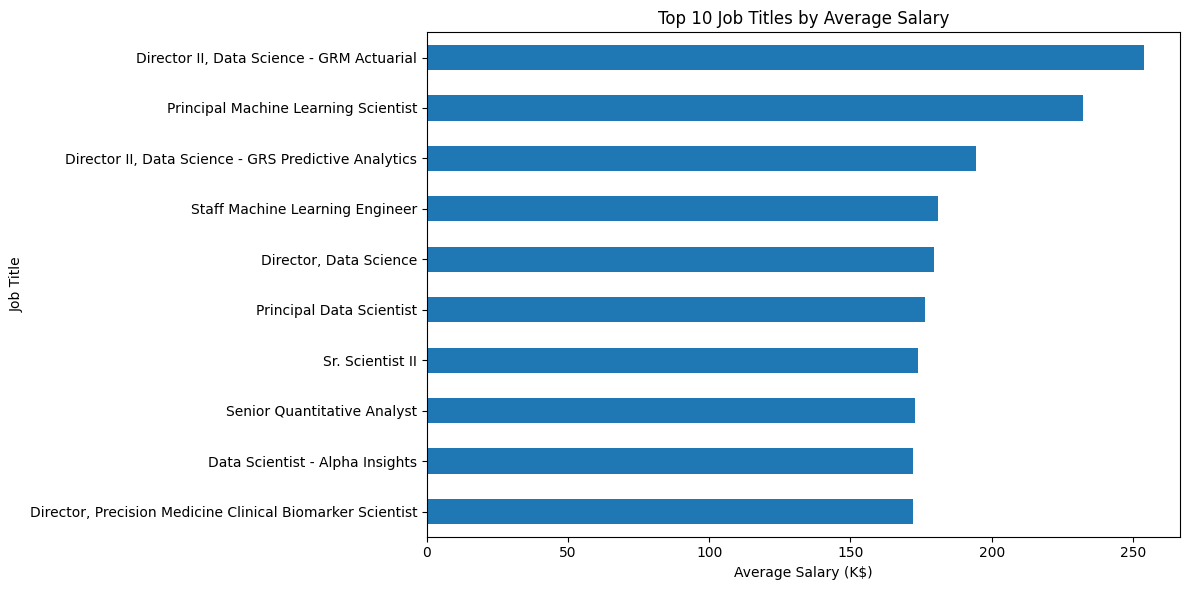

In [ ]:
# TOP 10 JOB TITLES BY SALARY
top_jobs = (
    df_clean
    .groupby('Job Title')['Average Salary']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_jobs.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Job Titles by Average Salary')
plt.xlabel('Average Salary (K$)')
plt.ylabel('Job Title')

plt.tight_layout()
plt.show()

###Insights:
Average salary vaires considerably across job titles. Senior and leadership-oriented roles such as Director, principal, and Staff positions appear among the highest-paying roles. This suggests that job title and level of responsibility may be important factors associated with salary.

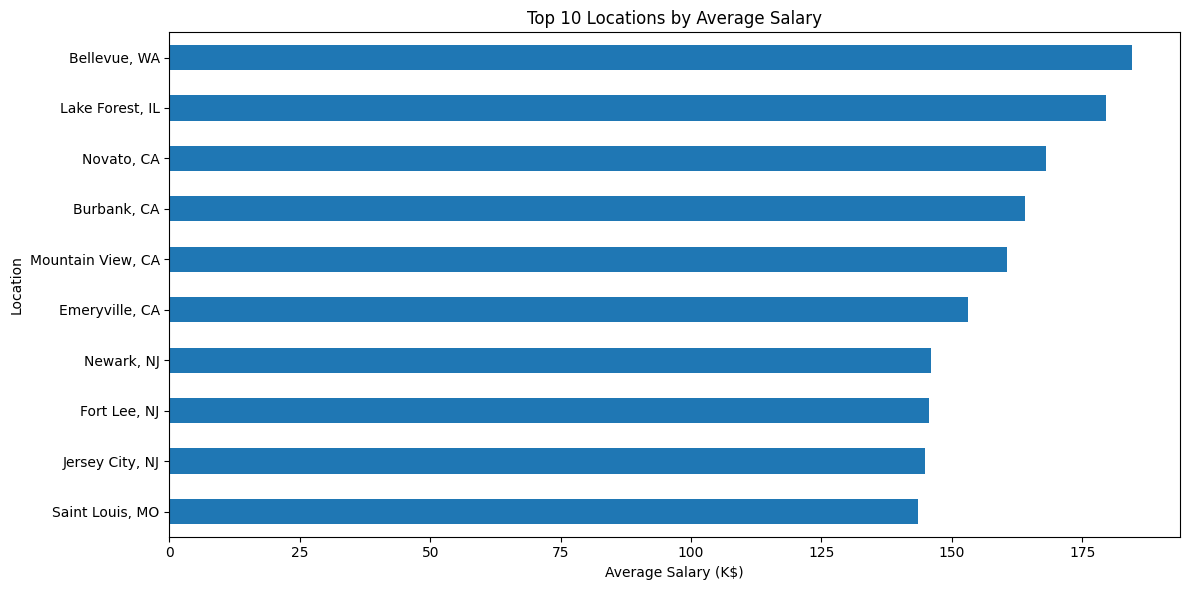

In [ ]:
# TOP 10 LOCATIONS BY SALARY
top_location = (
    df_clean
    .groupby('Location')['Average Salary']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_location.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Locations by Average Salary')
plt.xlabel('Average Salary (K$)')
plt.ylabel('Location')

plt.tight_layout()
plt.show()

###Insights:
The chart shows that average salary varies across different locations. Bellevue,WA has the highest average salary among the top 10 locations shown, followed by Lake Forest,IL and Novato,CA.

This indicates that location may an important factor associated with differences in job salaries.

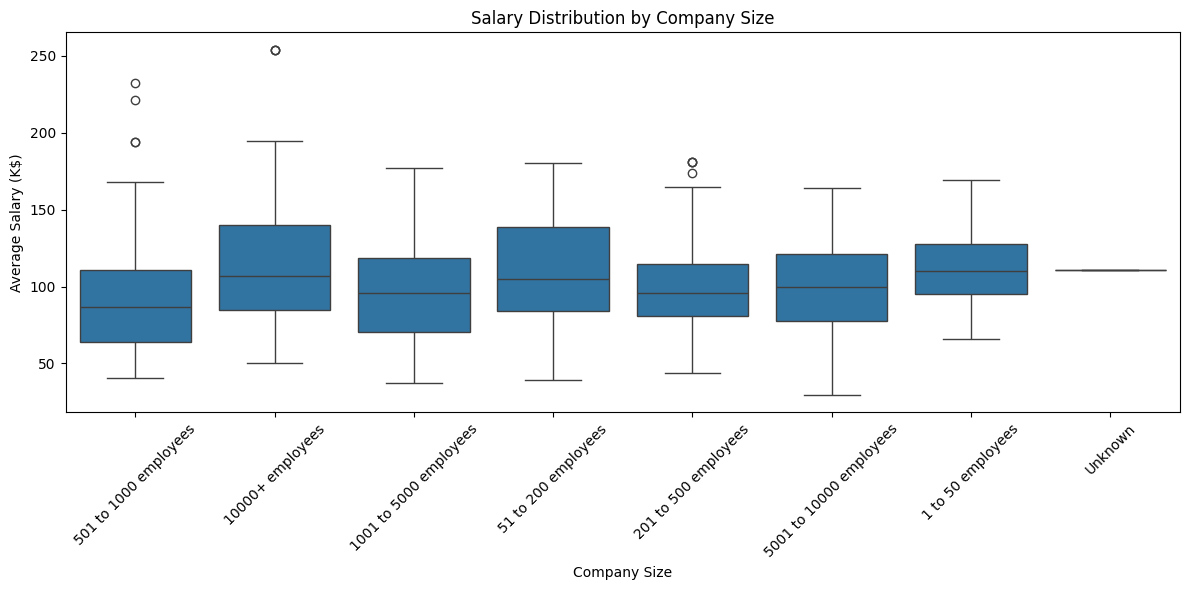

In [ ]:
# SALARY BY COMPANY SIZE
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x='Size',
    y='Average Salary'
)

plt.title('Salary Distribution by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Average Salary (K$)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Insights:
The Salary distribution varies across different company sizes. Companies with 1,000+ employees tend to show relatively higher median salaries and wide salary ranges,while smaller and medium-sized companies generally have lower median salaries.

This Suggest that company size may be asociated with salary levels, although
is not the only factor influencing salary.

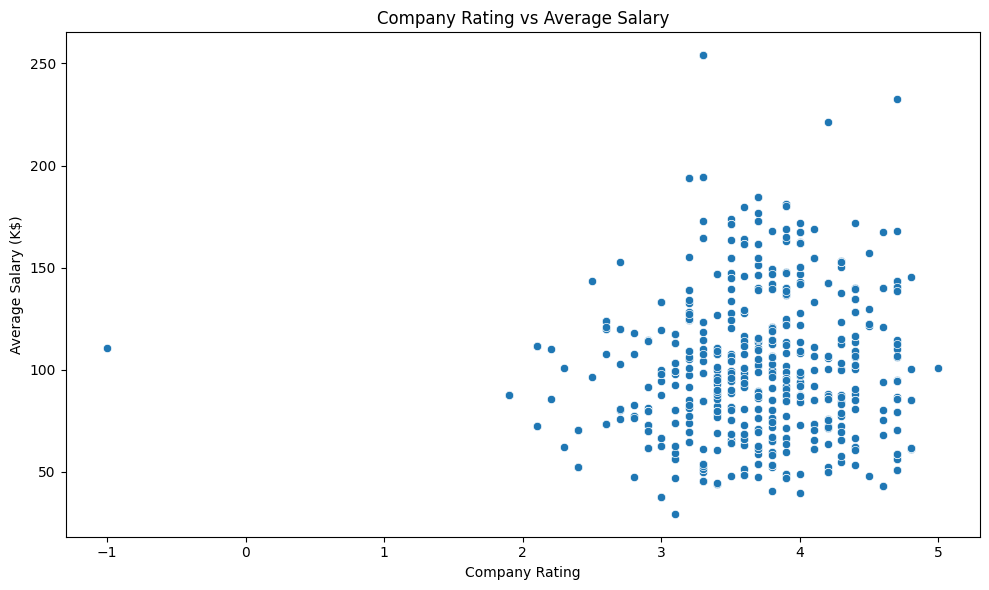

In [ ]:
# RATING VS SALARY
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Rating',
    y='Average Salary'
)

plt.title('Company Rating vs Average Salary')
plt.xlabel('Company Rating')
plt.ylabel('Average Salary (K$)')

plt.tight_layout()
plt.show()

###Insights:
The scatter plot shows no strong or consistent relationship between company rating and average salary. Salaries vary considerably among companies with similar ratings, indicating that company rating alone may not be a strong predictor of salary. Other factors, such as job title, location, company size, and industry, may also influence salary.

##Statistical Analysis


In [ ]:
# CORRELATION ANALYSIS
correlation = df_clean[
    'Rating'
].corr(
    df_clean['Average Salary']
)

print(
    "Correlation between Company Rating and Average Salary:",
    correlation
)

Correlation between Company Rating and Average Salary: 0.09338235865888413


In [ ]:
# PEARSON CORRELATION TEST
correlation, p_value = pearsonr(
    df_clean['Rating'],
    df_clean['Average Salary']
)

print("Correlation coefficient:", correlation)
print("P-value:", p_value)

if p_value < 0.05:
    print(
        "\nResult: The relationship is statistically significant."
    )
else:
    print(
        "\nResult: The relationship is not statistically significant."
    )


Correlation coefficient: 0.09338235865888418
P-value: 0.013993234631943704

Result: The relationship is statistically significant.


In [ ]:
# ANOVA - COMPANY SIZE
company_size_groups = []

for name, group in df_clean.groupby('Size'):
    salary_values = group['Average Salary'].dropna()

    # ANOVA requires groups with at least 2 observations
    if len(salary_values) >= 2:
        company_size_groups.append(salary_values)

f_stat_size, p_value_size = f_oneway(
    *company_size_groups
)

print("Company Size ANOVA")
print("------------------")
print("F-statistic:", f_stat_size)
print("P-value:", p_value_size)

if p_value_size < 0.05:
    print(
        "\nConclusion: Average salary differs significantly "
        "across company-size categories."
    )
else:
    print(
        "\nConclusion: There is no statistically significant "
        "difference in average salary across company-size categories."
    )

Company Size ANOVA
------------------
F-statistic: 5.408786741287675
P-value: 1.7833705410353523e-05

Conclusion: Average salary differs significantly across company-size categories.


In [ ]:
# JOB TITLE COUNTS
job_title_counts = (
    df_clean['Job Title']
    .value_counts()
)

print(
    job_title_counts.head(15)
)

Job Title
Data Scientist                                 128
Data Engineer                                   51
Senior Data Scientist                           30
Data Analyst                                    15
Senior Data Engineer                            14
Senior Data Analyst                             12
Lead Data Scientist                              8
Marketing Data Analyst                           6
Sr. Data Engineer                                6
Machine Learning Engineer                        5
Principal Data Scientist                         5
Senior Research Scientist-Machine Learning       4
Food Scientist - Developer                       4
Analytics Manager - Data Mart                    4
Sr. Data Engineer - Contract-to-Hire (Java)      4
Name: count, dtype: int64


In [ ]:
# ==========================================
# CELL 41: ANOVA - JOB TITLE
# ==========================================

# Select job titles with at least 5 observations
selected_titles = job_title_counts[
    job_title_counts >= 5
].index

job_title_groups = []

for title in selected_titles:
    salary_values = df_clean.loc[
        df_clean['Job Title'] == title,
        'Average Salary'
    ].dropna()

    if len(salary_values) >= 2:
        job_title_groups.append(salary_values)

print("Job Titles included in ANOVA:")
print(list(selected_titles))

if len(job_title_groups) >= 2:

    f_stat_title, p_value_title = f_oneway(
        *job_title_groups
    )

    print("\nF-statistic:", f_stat_title)
    print("P-value:", p_value_title)

else:
    print(
        "Not enough job-title groups for ANOVA."
    )

Job Titles included in ANOVA:
['Data Scientist', 'Data Engineer', 'Senior Data Scientist', 'Data Analyst', 'Senior Data Engineer', 'Senior Data Analyst', 'Lead Data Scientist', 'Marketing Data Analyst', 'Sr. Data Engineer', 'Machine Learning Engineer', 'Principal Data Scientist']

F-statistic: 32.09790417997438
P-value: 1.754460857808657e-40


In [ ]:
# JOB TITLE ANOVA INTERPRETATION
if len(job_title_groups) >= 2:

    if p_value_title < 0.05:
        print("""
Conclusion:

The p-value is less than 0.05.

Therefore, we reject the null hypothesis.

There is statistically significant evidence that
average salary differs across the selected job-title categories.
""")
    else:
        print("""
Conclusion:

The p-value is greater than 0.05.

Therefore, we fail to reject the null hypothesis.

There is insufficient evidence that average salary differs
across the selected job-title categories.
""")


Conclusion:

The p-value is less than 0.05.

Therefore, we reject the null hypothesis.

There is statistically significant evidence that
average salary differs across the selected job-title categories.



In [ ]:
# TUKEY HSD POST-HOC TEST
tukey_data = df_clean[
    df_clean['Job Title'].isin(selected_titles)
][
    ['Job Title', 'Average Salary']
].dropna()

if tukey_data['Job Title'].nunique() >= 2:

    tukey_result = pairwise_tukeyhsd(
        endog=tukey_data['Average Salary'],
        groups=tukey_data['Job Title'],
        alpha=0.05
    )

    print(tukey_result)

else:
    print(
        "Not enough job-title groups for Tukey HSD."
    )

                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
          group1                    group2           meandiff p-adj    lower    upper   reject
----------------------------------------------------------------------------------------------
             Data Analyst             Data Engineer   24.5431 0.0028    5.0222  44.0641   True
             Data Analyst            Data Scientist    39.825    0.0   21.6875  57.9625   True
             Data Analyst       Lead Data Scientist     94.95    0.0    65.854  124.046   True
             Data Analyst Machine Learning Engineer      38.6 0.0137    4.2803  72.9197   True
             Data Analyst    Marketing Data Analyst  -17.6333 0.7891  -49.7365  14.4698  False
             Data Analyst  Principal Data Scientist     110.0    0.0   75.6803 144.3197   True
             Data Analyst       Senior Data Analyst   17.1167 0.5361   -8.6231  42.8565  False
             Data Analyst      Senior Data Enginee

## STATISTICAL ANALYSIS SUMMARY

1. Company Rating vs Average Salary:
   Pearson correlation was used to measure the relationship.

2. Company Size vs Average Salary:
   One-way ANOVA was used to determine whether salary
   differs across company-size categories.

3. Job Title vs Average Salary:
   One-way ANOVA was used to determine whether salary
   differs across selected job-title categories.

4. Tukey HSD:
   Used as a post-hoc test to identify which specific
   job-title groups differ significantly.


##FINAL INSIGHTS


1. Salary varies considerably across job titles.

2. Senior and lead-level roles generally appear among
   the higher-paying positions.

3. Average salary varies across different locations.

4. Company size shows differences in salary distributions.

5. Company rating has a weak relationship with average salary.

6. Statistical testing helps determine whether observed
   salary differences are statistically significant.

7. Linear Regression and Random Forest were compared
   using MAE, RMSE, and R2.

8. The model with the higher R2 and lower error metrics
   is selected as the final model.

9. The preprocessing pipeline uses One-Hot Encoding for
   categorical variables and passes numerical variables
   directly to the model.


In [ ]:
# FINAL MODEL
if r2_lr >= r2_rf:
    final_model = lr_model
    final_model_name = 'Linear Regression'
else:
    final_model = rf_model
    final_model_name = 'Random Forest'

print("Final selected model:", final_model_name)

Final selected model: Random Forest


In [ ]:
# TRAIN FINAL MODEL
final_model.fit(
    X_train,
    Y_train
)

print(
    f"{final_model_name} trained successfully."
)

Random Forest trained successfully.


In [ ]:
# SAVE COMPLETE MODEL PIPELINE
model_filename = 'salary_prediction_model.pkl'

joblib.dump(
    final_model,
    model_filename
)

print("Model saved successfully!")
print("Saved file:", model_filename)

Model saved successfully!
Saved file: salary_prediction_model.pkl


In [ ]:
# VERIFY SAVED MODEL
print(
    "File exists:",
    os.path.exists('salary_prediction_model.pkl')
)

if os.path.exists('salary_prediction_model.pkl'):
    print("Model file is ready for deployment.")

File exists: True
Model file is ready for deployment.


In [ ]:
# SAVED MODEL
loaded_model = joblib.load(
    'salary_prediction_model.pkl'
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [ ]:
# TEST LOADED MODEL
loaded_predictions = loaded_model.predict(
    X_test
)

loaded_r2 = r2_score(
    Y_test,
    loaded_predictions
)

loaded_mae = mean_absolute_error(
    Y_test,
    loaded_predictions
)

print("Loaded Model Performance")
print("------------------------")
print("MAE:", loaded_mae)
print("R2 :", loaded_r2)

Loaded Model Performance
------------------------
MAE: 22.360933108792203
R2 : 0.3714202379014553


In [ ]:
#  SAMPLE NEW JOB PREDICTION
sample_job = pd.DataFrame({
    'Job Title': ['Data Scientist'],
    'Rating': [4.0],
    'Location': ['New York, NY'],
    'Headquarters': ['New York, NY'],
    'Size': ['1001 - 5000'],
    'Founded': [2000],
    'Type of ownership': ['Company - Private'],
    'Industry': ['Computer Hardware & Software'],
    'Sector': ['Information Technology'],
    'Revenue': ['$100 to $500 million'],
    'Competitors': ['Unknown']
})

predicted_salary = loaded_model.predict(
    sample_job
)

print(
    "Predicted Average Salary:",
    round(predicted_salary[0], 2),
    "K$"
)

Predicted Average Salary: 96.52 K$


## Conclusion

This project analyzed Glassdoor job posting data to understand salary patterns and identify factors associated with salary differences.

The exploratory analysis showed that average salary varies across job titles, locations, and company-size categories. Senior and lead-level positions generally appeared among the higher-paying roles.

Statistical analysis showed that company rating had a very weak relationship with average salary. Company size and job title showed statistically significant differences in average salary based on the ANOVA tests. Tukey's HSD post-hoc analysis was used to identify specific job-title groups with significant salary differences.

For machine learning, Linear Regression and Random Forest Regression were evaluated using MAE, RMSE, and R². The model with the best evaluation performance was selected as the final model.

The complete preprocessing and machine learning pipeline was saved using Joblib. The pipeline includes One-Hot Encoding for categorical variables, allowing the same preprocessing steps to be automatically applied when making predictions on new job data.

Overall, this project demonstrates the use of data cleaning, exploratory data analysis, statistical hypothesis testing, feature preprocessing, regression modeling, model evaluation, and model deployment preparation to predict estimated job salaries.

In [ ]:
import os

print(os.path.exists("salary_prediction_model.pkl"))

True


In [ ]:
from google.colab import files

files.download('salary_prediction_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>